# Quantum memory experiment with the `[[4,2,2]]` code
Qubit labeling:
```
1 -------- 2
|          |
|          |
|          |
3 -------- 4
```
Stabilizer tableau:
```
XXXX | IIIZ
ZZZZ | IIIX
-----------
XXII | ZIZI
ZZII | XIXI
```
I.e.
$$
\begin{align}
X_{L1} & = X_1X_2, ~~~ Z_{L1} = Z_1Z_3, \\
X_{L2} & = X_1X_3, ~~~ Z_{L2} = Z_1Z_2
\end{align}
$$

In [1]:
import numpy as np
import stim
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [124]:
ops = {
    "X1": np.array([1,1,0,0,0,0,0,0]),
    "Z1": np.array([0,0,0,0,1,0,1,0]),
    "X2": np.array([1,0,1,0,0,0,0,0]),
    "Z2": np.array([0,0,0,0,1,1,0,0]),
}
ops_2qb = {
    "ZZ": (ops["Z1"] + ops["Z2"]) % 2,
    "ZX": (ops["Z1"] + ops["X2"]) % 2,
    "XZ": (ops["X1"] + ops["Z2"]) % 2,
    "XX": (ops["X1"] + ops["X2"]) % 2,
}
ops_2qb

{'ZZ': array([0, 0, 0, 0, 0, 1, 1, 0], dtype=int32),
 'ZX': array([1, 0, 1, 0, 1, 0, 1, 0], dtype=int32),
 'XZ': array([1, 1, 0, 0, 1, 1, 0, 0], dtype=int32),
 'XX': array([0, 1, 1, 0, 0, 0, 0, 0], dtype=int32)}

In [125]:
def get_init_state_basis(init_state: str) -> np.ndarray:
    op_str = ""
    for i in range(len(init_state)):
        if init_state[i] in ["0", "1"]:
            op_str += "Z"
        elif init_state[i] in ["+", "-"]:
            op_str += "X"
    return ops_2qb[op_str]

In [ ]:
def op_to_str(op: np.ndarray) -> str:
    op_str = ""
    n_qb = int(len(op)/2)
    for i in range(n_qb):
        if op[i] == 1 and op[i+n_qb] == 0:
            op_str += "X"
        elif op[i] == 0 and op[i+n_qb] == 1:
            op_str += "Z"
        elif op[i] == 1 and op[i+n_qb] == 1:
            op_str += "Y"
        elif op[i] == 0 and op[i+n_qb] == 0:
            op_str += "I"
    return op_str

In [176]:
def get_circuit(init_state: str, qec_rounds: int, p: float = 0, mode: str = "naive") -> stim.Circuit:
    circuit = stim.Circuit()
    if init_state == "00":
        pass
    elif init_state == "10":
        circuit.append("X", [0,1])
    elif init_state == "01":
        circuit.append("X", [0,2])
    elif init_state == "11":
        circuit.append("X", [1,2])
    elif init_state == "++":
        circuit.append("H", [0,1,2,3])
    else:
        raise ValueError(f"Unknown initial state: {init_state}")

    if mode == "naive":
        for _ in range(qec_rounds):
            circuit.append("CNOT", [0,4,1,4,2,4,3,4])
            if p > 0:
                circuit.append("DEPOLARIZE2", [0,4,1,4,2,4,3,4], p)
            circuit.append("MR", 4)
            circuit.append("H", 5)
            circuit.append("CNOT", [5,0,5,1,5,2,5,3])
            if p > 0:
                circuit.append("DEPOLARIZE2", [0,4,1,4,2,4,3,4], p)
            circuit.append("H", 5)
            circuit.append("MR", 5)
    elif mode == "reichardt":
        for _ in range(qec_rounds):
            circuit.append("H", 5)
            cnots = [
                [0,4],
                [5,1],
                [1,4],
                [5,0],
                [2,4],
                [5,3],
                [3,4],
                [5,2],
            ]
            for cnot in cnots:
                circuit.append("CNOT", cnot)
                if p > 0:
                    circuit.append("DEPOLARIZE2", cnot, p)
            circuit.append("H", 5)
            circuit.append("MR", 4)
            circuit.append("MR", 5)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    # Final data qubit measurement
    mmt_op = get_init_state_basis(init_state)
    circuit.append("H", mmt_op[:4].nonzero()[0])

    circuit.append("M", [0,1,2,3])
    return circuit

In [192]:
def get_detectors(syndrome_bits, measurement_basis, data_qubit_ro):
    X_syndromes = syndrome_bits[1::2].tolist()
    Z_syndromes = syndrome_bits[0::2].tolist()

    if set(measurement_basis) - {"I"} == {"Z"}:
        Z_syndromes.append(np.sum(data_qubit_ro) % 2)
    elif set(measurement_basis) - {"I"} == {"X"}:
        X_syndromes.append(np.sum(data_qubit_ro) % 2)
    else:
        raise ValueError(f"Measurement basis {measurement_basis} is not possible.")

    X_syndromes = np.array(X_syndromes)
    Z_syndromes = np.array(Z_syndromes)
    X_detectors = (X_syndromes[0:-1] + X_syndromes[1:]) % 2
    Z_detectors = (Z_syndromes[0:-1] + Z_syndromes[1:]) % 2

    return X_detectors, Z_detectors

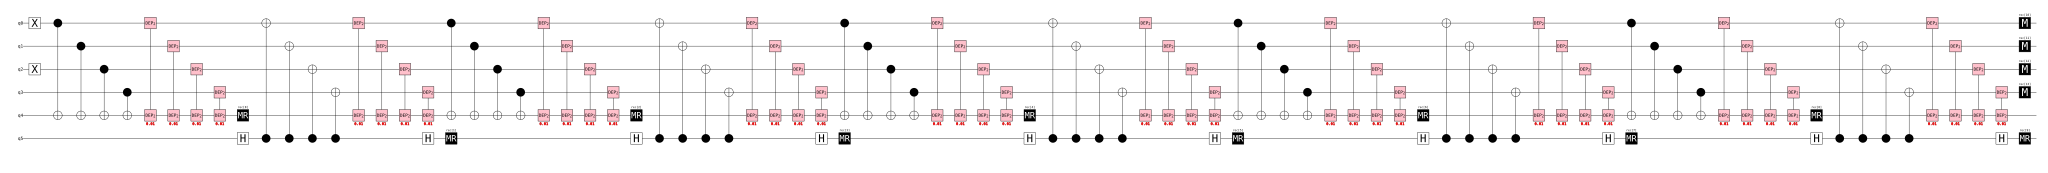

In [177]:
initial_state = "01"
qec_rounds = 5
circuit = get_circuit(initial_state, qec_rounds, p=0.01)
circuit.diagram('timeline-svg')

In [ ]:
X_idx = get_init_state_basis(initial_state)[:4].nonzero()[0]
Z_idx = get_init_state_basis(initial_state)[4:].nonzero()[0]
involved_qbs = set(set(Z_idx) | set(X_idx))

In [ ]:
n_shots = 10
sampler = circuit.compile_sampler()

for shot in sampler.sample(shots=n_shots):
    stabilizers = np.array(shot[0:2*qec_rounds], dtype=int)
    X_stabs = stabilizers[1::2]
    Z_stabs = stabilizers[0::2]
    final_data_readout = np.array(shot[2*qec_rounds:], dtype=int)
    res = np.sum([final_data_readout[i] for i in involved_qbs]) % 2
    X_syndromes = (X_stabs[0:-1] + X_stabs[1:]) % 2
    Z_syndromes = (Z_stabs[0:-1] + Z_stabs[1:]) % 2
    print(X_syndromes)
    print(Z_syndromes)
    print(res)

[0 0 0 0]
[0 0 0 0]
1
[0 0 0 0]
[0 0 0 0]
1
[0 0 0 0]
[0 0 0 0]
1
[0 0 0 0]
[0 0 0 0]
1
[0 0 0 0]
[0 0 0 0]
1
[0 0 0 0]
[0 0 0 0]
1
[0 0 0 0]
[0 0 0 0]
1
[0 0 0 0]
[0 0 0 0]
1
[0 0 0 0]
[0 0 0 0]
1
[0 0 0 0]
[0 0 0 0]
1


In [160]:
qec_rounds = 5
p = 0.01
n_shots = 100

for init_state in ["00", "10", "01", "11", "++"]:
    circuit = get_circuit(init_state, qec_rounds, p)
    X_idx = get_init_state_basis(init_state)[:4].nonzero()[0]
    Z_idx = get_init_state_basis(init_state)[4:].nonzero()[0]
    involved_qbs = set(set(Z_idx) | set(X_idx))

    sampler = circuit.compile_sampler()

    avg_res = []
    for shot in sampler.sample(shots=n_shots):
        stabilizers = np.array(shot[0:2*qec_rounds], dtype=int)
        X_stabs = stabilizers[1::2]
        Z_stabs = stabilizers[0::2]
        final_data_readout = np.array(shot[2*qec_rounds:], dtype=int)
        res = np.sum([final_data_readout[i] for i in involved_qbs]) % 2
        X_syndromes = (X_stabs[0:-1] + X_stabs[1:]) % 2
        Z_syndromes = (Z_stabs[0:-1] + Z_stabs[1:]) % 2
        avg_res.append(res)

    print(f"Initial state: {init_state}")
    print(f"Measurement basis: {op_to_str(get_init_state_basis(init_state))}")
    print(f"Result = {np.average(avg_res)}")

Initial state: 00
Measurement basis: IZZI
Result = 0.05
Initial state: 10
Measurement basis: IZZI
Result = 0.86
Initial state: 01
Measurement basis: IZZI
Result = 0.9
Initial state: 11
Measurement basis: IZZI
Result = 0.08
Initial state: ++
Measurement basis: IXXI
Result = 0.13


p = 0.0001
Result = 0.0015
p = 0.001
Result = 0.0093
p = 0.002
Result = 0.0205
p = 0.005
Result = 0.0508
p = 0.01
Result = 0.0952


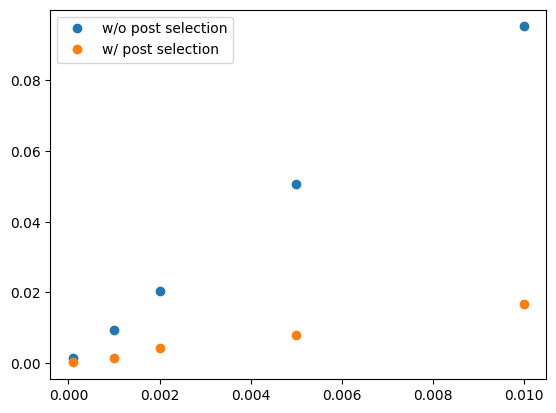

In [ ]:
qec_rounds = 5
n_shots = 10000
init_state = "++"

results_per_p = {}
results_per_p_post = {}
for p in [0.0001, 0.001, 0.002, 0.005, 0.01,]:
    circuit = get_circuit(init_state, qec_rounds, p)
    X_idx = get_init_state_basis(init_state)[:4].nonzero()[0]
    Z_idx = get_init_state_basis(init_state)[4:].nonzero()[0]
    involved_qbs = set(set(Z_idx) | set(X_idx))

    sampler = circuit.compile_sampler()

    avg_res = []
    avg_res_post = []
    for shot in sampler.sample(shots=n_shots):
        stabilizers = np.array(shot[0:2*qec_rounds], dtype=int)
        X_stabs = stabilizers[1::2]
        Z_stabs = stabilizers[0::2]
        final_data_readout = np.array(shot[2*qec_rounds:], dtype=int)
        res = np.sum([final_data_readout[i] for i in involved_qbs]) % 2
        X_syndromes = (X_stabs[0:-1] + X_stabs[1:]) % 2
        Z_syndromes = (Z_stabs[0:-1] + Z_stabs[1:]) % 2
        avg_res.append(res)
        if np.sum(X_syndromes) + np.sum(Z_syndromes) == 0:
            avg_res_post.append(res)

    print(f"p = {p}")
    results_per_p[p] = np.average(avg_res)
    print(f"Result = {np.average(avg_res)}")
    results_per_p_post[p] = np.average(avg_res_post)

plt.plot(results_per_p.keys(), results_per_p.values(), "o", label="w/o post selection")
plt.plot(results_per_p_post.keys(), results_per_p_post.values(), "o", label="w/ post selection")
plt.legend()
plt.xlabel("Error rate p")
plt.ylabel("Logical error probability")
plt.show()

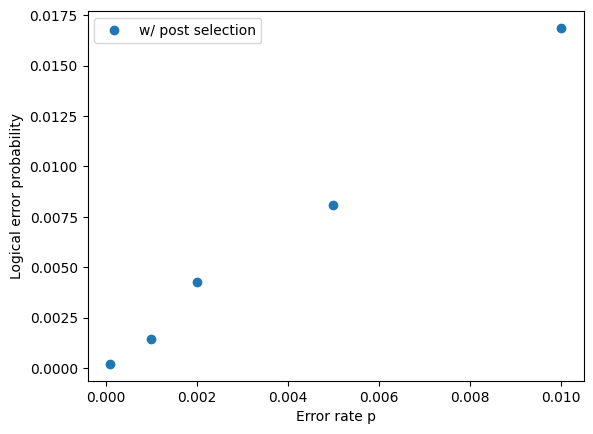

In [174]:
plt.plot(results_per_p_post.keys(), results_per_p_post.values(), "o", label="w/ post selection")
plt.legend()
plt.xlabel("Error rate p")
plt.ylabel("Logical error probability")
plt.show()

# Reichardt trick for fault tolerance

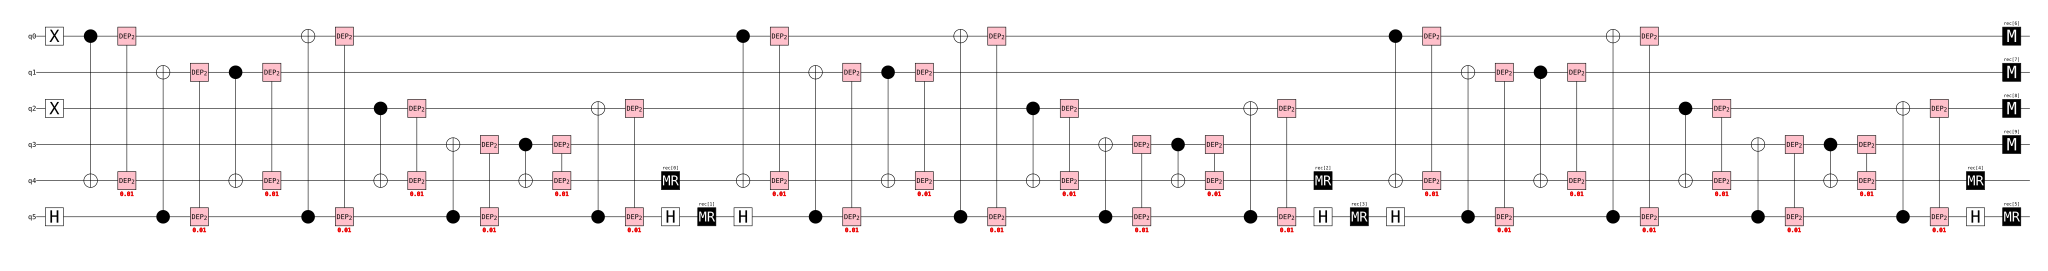

In [178]:
initial_state = "01"
qec_rounds = 3
circuit = get_circuit(initial_state, qec_rounds, p=0.01, mode="reichardt")
circuit.diagram('timeline-svg')

p = 1e-05
Result = 0.00011
p = 0.0001
Result = 0.0013
p = 0.0002
Result = 0.00205
p = 0.0005
Result = 0.00525
p = 0.00075
Result = 0.00787
p = 0.001
Result = 0.0109


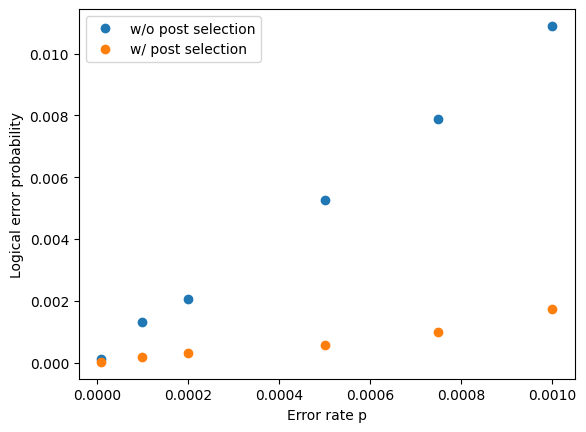

In [196]:
qec_rounds = 5
n_shots = 100000
init_state = "++"

results_per_p = {}
results_per_p_post = {}
for p in 0.1*np.array([0.0001, 0.001, 0.002, 0.005, 0.0075, 0.01,]):
    circuit = get_circuit(init_state, qec_rounds, p)
    X_idx = get_init_state_basis(init_state)[:4].nonzero()[0]
    Z_idx = get_init_state_basis(init_state)[4:].nonzero()[0]
    involved_qbs = set(set(Z_idx) | set(X_idx))

    sampler = circuit.compile_sampler()

    avg_res = []
    avg_res_post = []
    for shot in sampler.sample(shots=n_shots):
        stabilizers = np.array(shot[0:2*qec_rounds], dtype=int)
        X_stabs = stabilizers[1::2]
        Z_stabs = stabilizers[0::2]
        final_data_readout = np.array(shot[2*qec_rounds:], dtype=int)
        res = np.sum([final_data_readout[i] for i in involved_qbs]) % 2
        X_detectors, Z_detectors = get_detectors(stabilizers, op_to_str(get_init_state_basis(init_state)), final_data_readout)

        avg_res.append(res)
        if np.sum(X_detectors) + np.sum(Z_detectors) == 0:
            avg_res_post.append(res)

    print(f"p = {p}")
    results_per_p[p] = np.average(avg_res)
    print(f"Result = {np.average(avg_res)}")
    results_per_p_post[p] = np.average(avg_res_post)

plt.plot(results_per_p.keys(), results_per_p.values(), "o", label="w/o post selection")
plt.plot(results_per_p_post.keys(), results_per_p_post.values(), "o", label="w/ post selection")
plt.legend()
plt.xlabel("Error rate p")
plt.ylabel("Logical error probability")
plt.show()

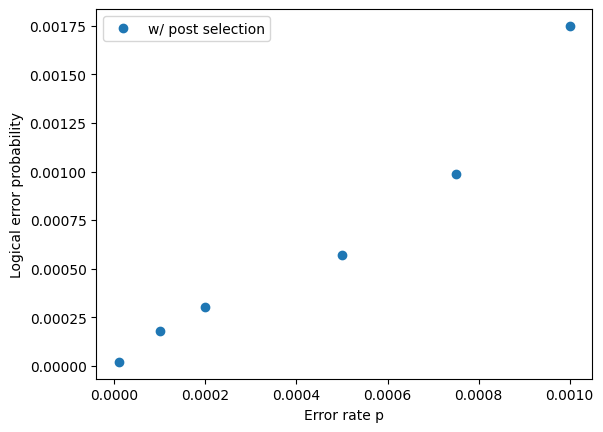

In [ ]:
plt.plot(results_per_p_post.keys(), results_per_p_post.values(), "o", label="w/ post selection")
plt.legend()
plt.xlabel("Error rate p")
plt.ylabel("Logical error probability")
plt.show()